# 01 — Flickr8k: Data Exploration

Para la primera reunión:
- ¿Cuántas muestras tenemos?
- ¿Está balanceado? (longitud de captions, palabras frecuentes)
- ¿Datos normalizados?
- ¿Qué shape tienen los batches?

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

DATA_DIR = ROOT / 'data' / 'flickr8k'
IMAGES_DIR = DATA_DIR / 'Images'
CAPTIONS_CSV = DATA_DIR / 'captions.txt'
print('Data dir:', DATA_DIR)

Data dir: c:\Users\Usuario\Desktop\CARRERA DADES\TERCERO CARRERA\SEGUNDO SEMESTRE\DEEPLEARNING\proyectodeep\data\flickr8k


## 1. Tamaño del dataset

In [2]:
df = pd.read_csv(CAPTIONS_CSV)
print(f'Filas (image, caption): {len(df):,}')
print(f'Imágenes únicas:        {df["image"].nunique():,}')
print(f'Captions por imagen:    {len(df) / df["image"].nunique():.2f}')
df.head()

Filas (image, caption): 40,455
Imágenes únicas:        8,091
Captions por imagen:    5.00


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


## 2. Distribución de longitud de captions

Longitud media:  10.8 palabras
Mediana:         10
Min / Max:       1 / 37


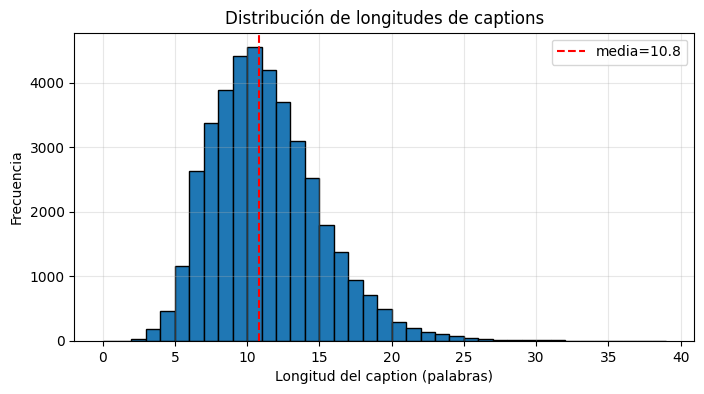

In [3]:
from src.vocabulary import simple_tokenize

lens = df['caption'].astype(str).map(lambda s: len(simple_tokenize(s)))
print(f'Longitud media:  {lens.mean():.1f} palabras')
print(f'Mediana:         {lens.median():.0f}')
print(f'Min / Max:       {lens.min()} / {lens.max()}')

plt.figure(figsize=(8, 4))
plt.hist(lens, bins=range(0, 40), edgecolor='black')
plt.axvline(lens.mean(), color='red', linestyle='--', label=f'media={lens.mean():.1f}')
plt.xlabel('Longitud del caption (palabras)')
plt.ylabel('Frecuencia')
plt.title('Distribución de longitudes de captions')
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 3. Palabras más frecuentes y vocabulario

Vocabulario total (todas las palabras): 8,493
  Con threshold >=  1:  8,493 palabras
  Con threshold >=  3:  4,080 palabras
  Con threshold >=  5:  2,978 palabras
  Con threshold >= 10:  1,967 palabras


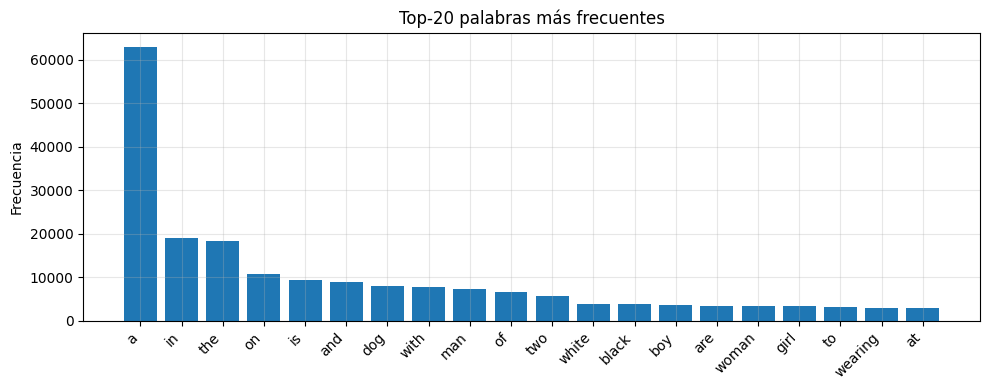

In [4]:
from collections import Counter

counter = Counter()
for cap in df['caption'].astype(str):
    counter.update(simple_tokenize(cap))

print(f'Vocabulario total (todas las palabras): {len(counter):,}')
for thr in [1, 3, 5, 10]:
    n = sum(1 for c in counter.values() if c >= thr)
    print(f'  Con threshold >= {thr:2}:  {n:,} palabras')

top = counter.most_common(20)
words, counts = zip(*top)
plt.figure(figsize=(10, 4))
plt.bar(words, counts)
plt.xticks(rotation=45, ha='right')
plt.title('Top-20 palabras más frecuentes')
plt.ylabel('Frecuencia'); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 4. Ejemplos de imágenes con sus captions

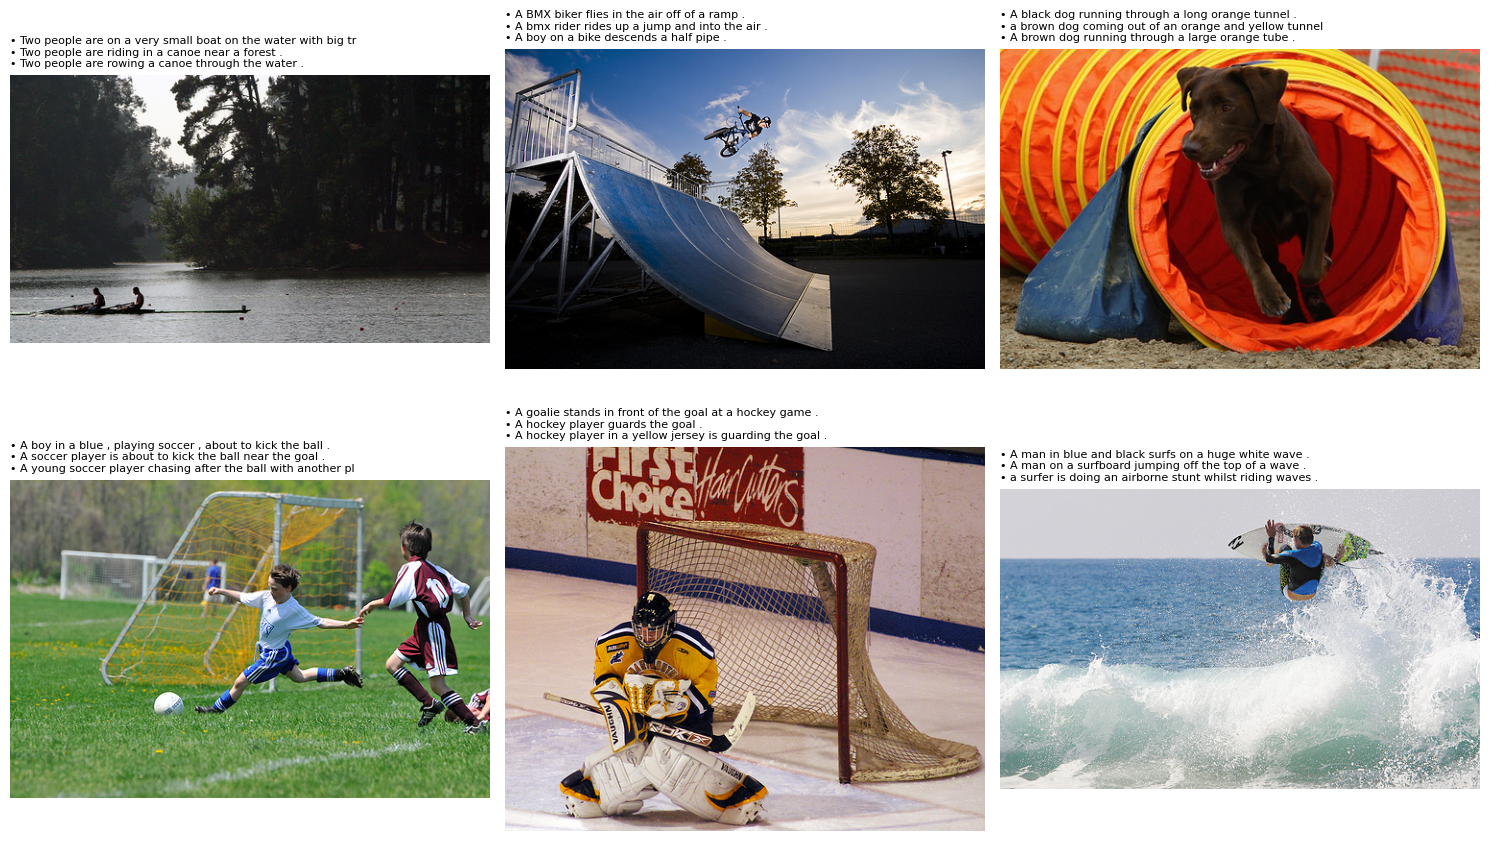

In [5]:
sample_images = df['image'].drop_duplicates().sample(6, random_state=0).tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, img_name in zip(axes.flat, sample_images):
    img = Image.open(IMAGES_DIR / img_name)
    captions = df[df['image'] == img_name]['caption'].tolist()
    ax.imshow(img); ax.axis('off')
    title = '\n'.join(f'• {c[:60]}' for c in captions[:3])
    ax.set_title(title, fontsize=8, loc='left')
plt.tight_layout(); plt.show()

## 5. Verificar el DataLoader

Comprobamos shapes, normalización, y splits train/val/test.

In [6]:
from src.vocabulary import build_vocab
from src.dataset import get_loaders

vocab = build_vocab(CAPTIONS_CSV, threshold=5)
print(f'Vocab size: {len(vocab)}')

train_loader, val_loader, test_loader, (tr, va, te) = get_loaders(
    images_dir=IMAGES_DIR,
    captions_csv=CAPTIONS_CSV,
    vocab=vocab,
    batch_size=16,
    num_workers=0,
)
print(f'Train images: {len(tr):,}  Val: {len(va):,}  Test: {len(te):,}')
print(f'Train batches: {len(train_loader):,}')

Vocab size: 2982
Train images: 6,091  Val: 1,000  Test: 1,000
Train batches: 1,904


In [7]:
images, captions, lengths = next(iter(train_loader))
print(f'images.shape   = {tuple(images.shape)}   dtype={images.dtype}')
print(f'captions.shape = {tuple(captions.shape)}   dtype={captions.dtype}')
print(f'lengths        = {lengths[:8]} ...')
print(f'images mean    = {images.mean():.3f}  std = {images.std():.3f}  (normalizado con ImageNet stats)')
print()
print('Caption decodificado de la primera muestra:')
print(' ', vocab.decode(captions[0].tolist()))

c:\Users\Usuario\Desktop\CARRERA DADES\TERCERO CARRERA\SEGUNDO SEMESTRE\DEEPLEARNING\proyectodeep\.venv\lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


images.shape   = (16, 3, 224, 224)   dtype=torch.float32
captions.shape = (16, 19)   dtype=torch.int64
lengths        = [19, 17, 15, 13, 13, 13, 13, 12] ...
images mean    = 0.142  std = 1.166  (normalizado con ImageNet stats)

Caption decodificado de la primera muestra:
  a white dog with patches of brown and black on his eye is running through green grass


## 📋 Conclusiones para la reunión

- **40.455 pares** (image, caption) → **8.091 imágenes únicas** × 5 captions cada una.
- Captions cortos (mediana ~10-12 palabras), distribución sesgada a la derecha.
- Vocabulario reducido a ~2.500 palabras con `threshold=5` (descartamos las muy raras).
- Imágenes normalizadas con estadísticas de ImageNet (porque usamos un encoder pre-entrenado).
- Split: ~6.091 train / 1.000 val / 1.000 test.
- Cada batch: `images [B,3,224,224]`, `captions [B,T]`, `lengths` (lista).